In [1]:
import deeplabcut
from deeplabcut.pose_estimation_pytorch.data.transforms import build_transforms
import cv2
import matplotlib.pyplot as plt
import os
import random

Loading DLC 3.0.0rc13...


c:\Users\jiefei\anaconda3\envs\DEEPLABCUT\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

def load_and_transform_with_cv2(image_path, transform):
    image = cv2.imread(image_path)
    # Convert BGR to RGB (Albumentations expects RGB)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    transformed = transform(image=image,
        keypoints=[],
        class_labels=[],
        bboxes=[],
        bbox_labels=[])
    
    return transformed['image']

def compare_image(transform, image_path):
    transformed_image = load_and_transform_with_cv2(image_path, transform)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.subplot(1, 2, 2)
    plt.imshow(transformed_image)
    plt.title('Transformed Image')
    plt.show()

In [47]:
from deeplabcut.core.config import read_config_as_dict
import deeplabcut.pose_estimation_pytorch as dlc_torch
import yaml

config_path = "projects/rat_pose/config.yaml"
loader = dlc_torch.DLCLoader(
    config=config_path,  
    trainset_index=0,
    shuffle=1,
)

# Get the pytorch config
pytorch_config_path = loader.model_folder / "pytorch_config.yaml"
model_cfg = read_config_as_dict(pytorch_config_path)

# repace train data params with dropin params
with open("projects/rat_pose/train_dropin.yaml", 'r') as f:
    dropin_param = yaml.safe_load(f)
model_cfg["data"]["train"] = dropin_param

model_cfg["data"]["train"].pop("affine")
model_cfg["data"]["train"].pop("crop_sampling")
model_cfg["data"]["train"].pop("normalize_images")

transform = build_transforms(model_cfg["data"]["train"])
transform

Compose([
  MotionBlur(always_apply=False, p=0.5, blur_limit=(3, 7), allow_shifted=True),
  GaussNoise(always_apply=False, p=0.5, var_limit=(0, 162.5625), per_channel=True, mean=0),
  PadIfNeeded(always_apply=False, p=1.0, min_height=None, min_width=None, pad_height_divisor=32, pad_width_divisor=32, position=PositionType.RANDOM, border_mode=4, value=None, mask_value=None),
  ImageCompression(always_apply=False, p=1, quality_lower=20, quality_upper=90, compression_type=0),
  RandomSunFlare(always_apply=False, p=1, flare_roi=(0.0, 0.0, 1.0, 1), angle_lower=0.0, angle_upper=1.0, num_flare_circles_lower=1, num_flare_circles_upper=4, src_radius=40, src_color=[255, 245, 230]),
  RandomRain(always_apply=False, p=1, slant_lower=-1, slant_upper=1, drop_length=15, drop_width=4, drop_color=[200, 200, 200], blur_value=7, brightness_coefficient=0.8, rain_type='drizzle'),
  Sharpen(always_apply=False, p=0.5, alpha=(0, 1.0), lightness=(0.5, 1.0)),
  HueSaturationValue(always_apply=False, p=1, hue_shi

In [18]:
model_cfg["data"]["train"]

{'gaussian_noise': 12.75,
 'motion_blur': True,
 'auto_padding': {'pad_width_divisor': 32, 'pad_height_divisor': 32},
 'transform': [{'augmentation': 'ImageCompression',
   'quality_lower': 20,
   'quality_upper': 90,
   'p': 1.0},
  {'augmentation': 'RandomSunFlare',
   'flare_roi': [0.4, 0.4, 0.6, 0.6],
   'angle_lower': 0.45,
   'angle_upper': 0.55,
   'num_flare_circles_lower': 5,
   'num_flare_circles_upper': 15,
   'src_radius': 100,
   'src_color': [255, 255, 100]},
  {'augmentation': 'RandomRain',
   'slant_lower': -1,
   'slant_upper': 1,
   'drop_length': 15,
   'drop_width': 4,
   'drop_color': [180, 180, 180],
   'blur_value': 5,
   'brightness_coefficient': 0.8,
   'rain_type': 'drizzle',
   'p': 1.0},
  {'augmentation': 'Sharpen',
   'alpha': [1.0, 1.0],
   'lightness': [1.0, 1.0],
   'p': 1.0},
  {'augmentation': 'HueSaturationValue',
   'hue_shift_limit': [-5, 5],
   'sat_shift_limit': [-60, 60],
   'val_shift_limit': [-20, 20],
   'p': 1}]}

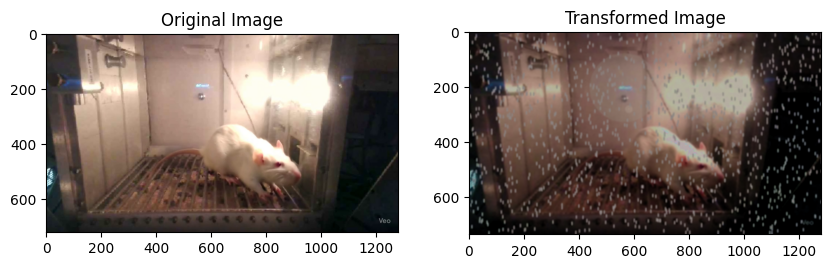

In [51]:
image_path = "projects/rat_pose/labeled-data/ai1/img001.png"
compare_image(transform, image_path)

# Random Samples

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).



Folder: ai1 (sampling 2 images)
  - img049.png


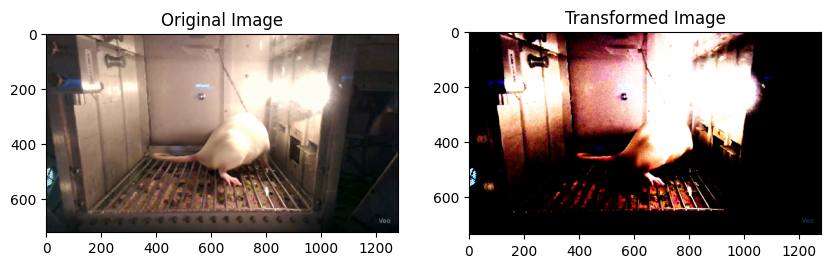

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


  - img183.png


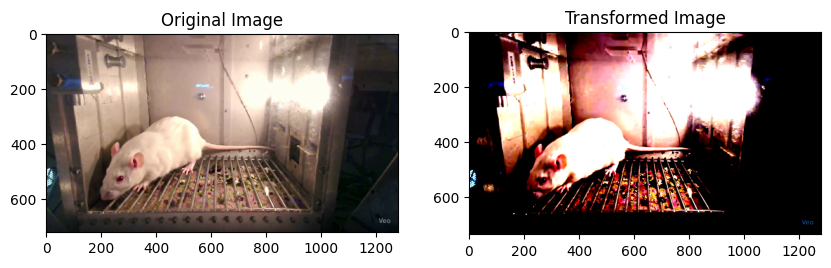

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).



Folder: ai2 (sampling 2 images)
  - img084.png


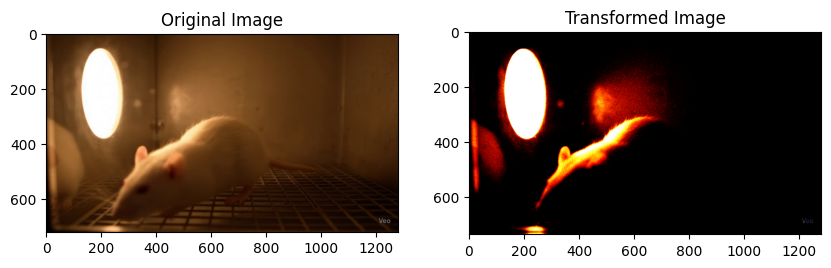

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


  - img093.png


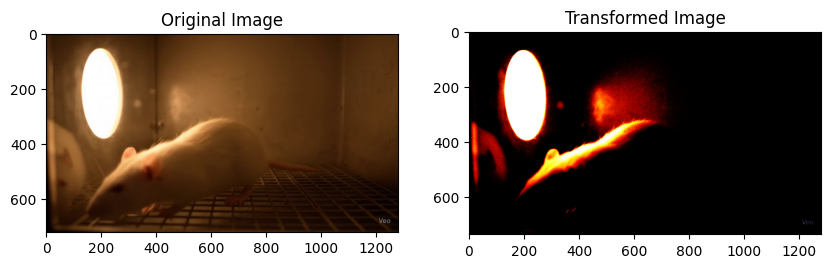

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).



Folder: ai3 (sampling 2 images)
  - img110.png


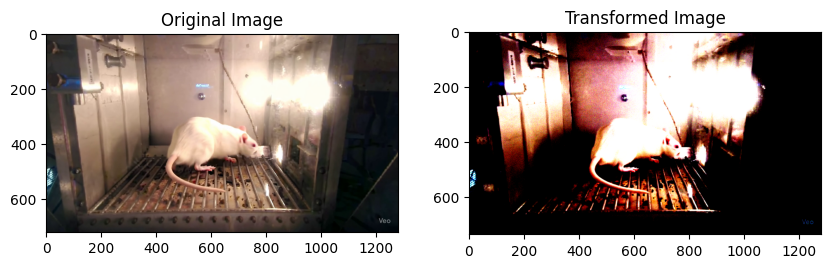

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


  - img105.png


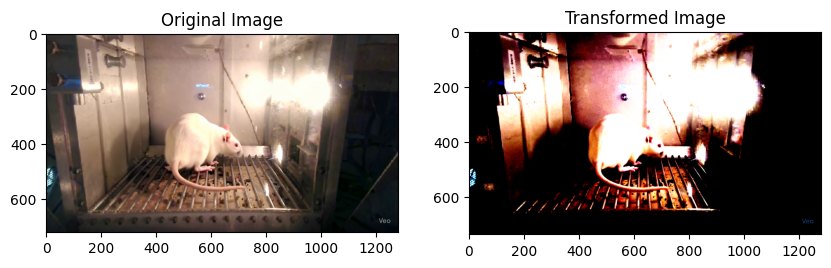

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).



Folder: ai4 (sampling 2 images)
  - img178.png


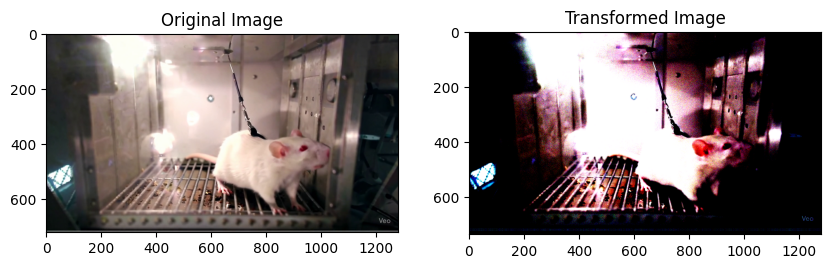

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


  - img095.png


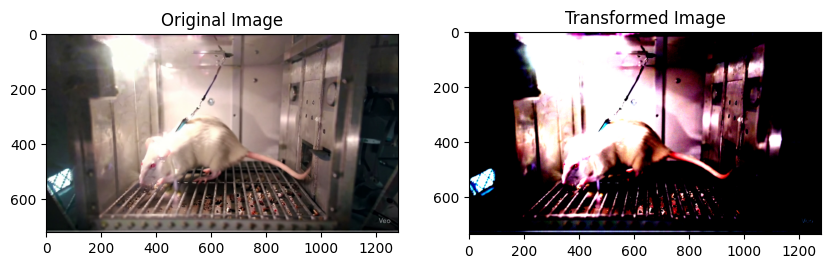

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).



Folder: ai5 (sampling 2 images)
  - img060.png


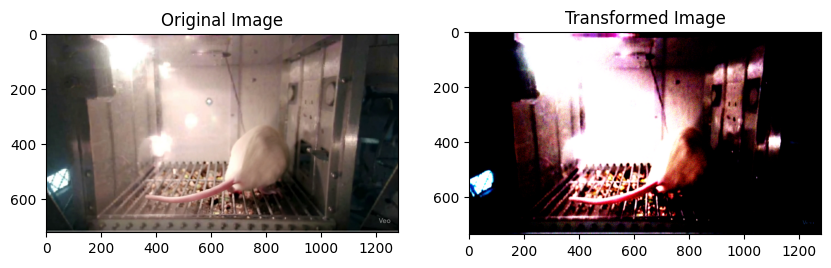

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


  - img037.png


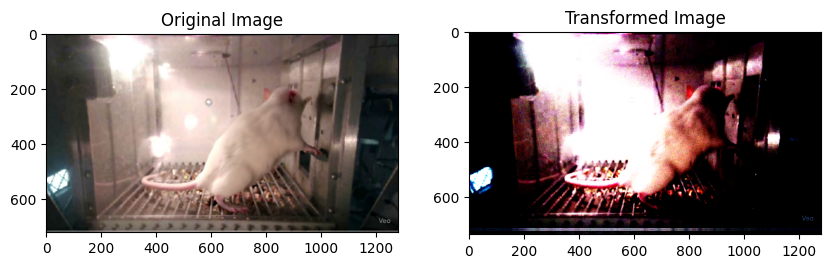

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).



Folder: ai6 (sampling 2 images)
  - img056.png


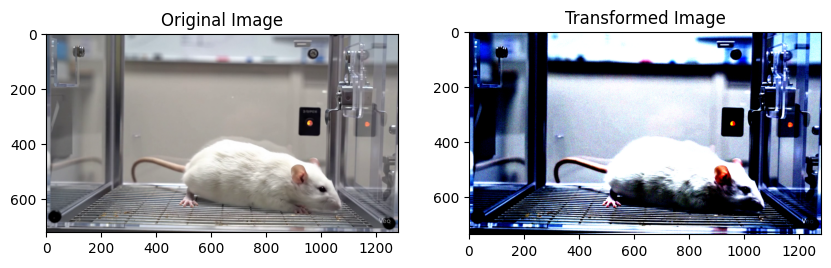

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


  - img033.png


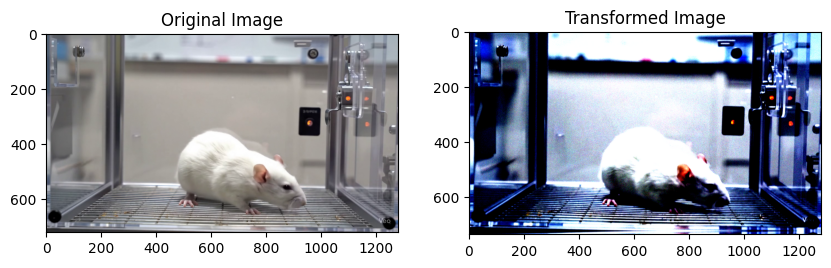

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).



Folder: ai7 (sampling 2 images)
  - img118.png


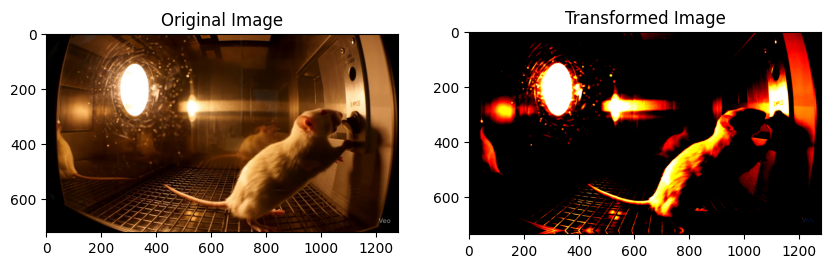

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


  - img162.png


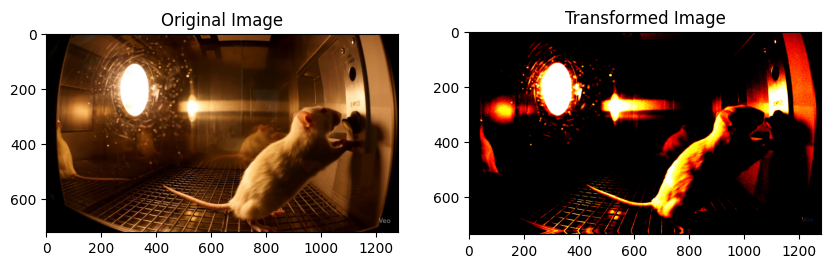

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).



Folder: ai8 (sampling 2 images)
  - img145.png


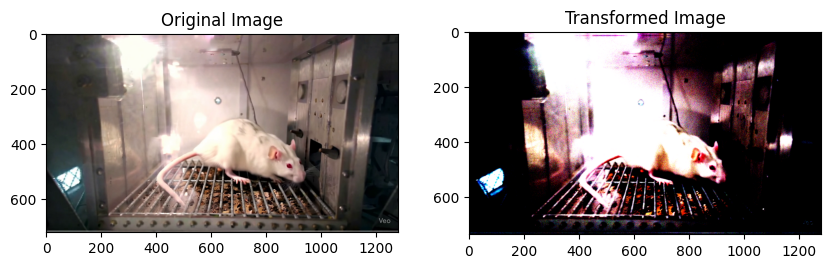

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


  - img009.png


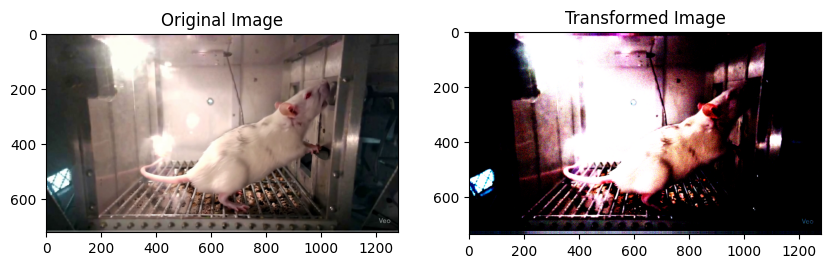

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).



Folder: Camera4_stitched (sampling 2 images)
  - img40473.png


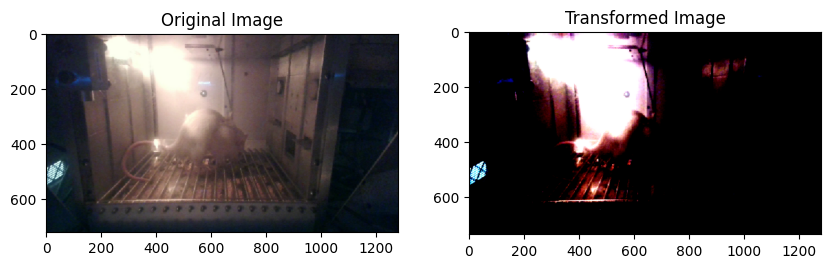

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


  - img33985.png


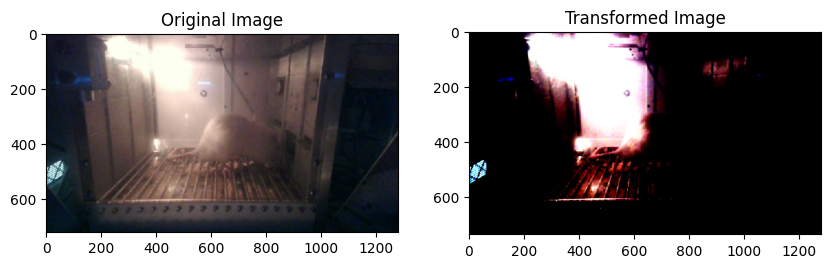

In [6]:
n = 2
labeled_data_path = "projects/rat_pose/labeled-data"
folders = [f for f in os.listdir(labeled_data_path) 
           if os.path.isdir(os.path.join(labeled_data_path, f))]

# For each folder, sample n images
for folder in folders:
    folder_path = os.path.join(labeled_data_path, folder)
    
    # Get all image files in the folder
    image_files = [f for f in os.listdir(folder_path) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    # Sample n images (or all if fewer than n)
    sample_size = min(n, len(image_files))
    sampled_images = random.sample(image_files, sample_size)
    
    print(f"\nFolder: {folder} (sampling {sample_size} images)")
    
    # Show transformed vs original for each sampled image
    for img_file in sampled_images:
        image_path = os.path.join(folder_path, img_file)
        print(f"  - {img_file}")
        compare_image(transform, image_path)